### Read-in downloaded data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
!ls csv

0e9cd673-8e06-4810-b370-8b9930ee312a.csv
2021-10-28-cleaned.csv
2021-10-28.csv
2022-01-03.csv
2022-01-07.csv
2022-01-10.csv
50c39121-3de2-4b6b-b134-bb51732c1d6f.csv
viewer_lat_long_centroids.csv


search data

In [4]:
data = pd.read_csv("csv/2022-01-07.csv", index_col = False)

/Users/lhuang/opt/miniconda3/envs/tensorflow2.5/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3170: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122951292 entries, 0 to 122951291
Data columns (total 18 columns):
search_id                  object
user_id                    object
broadcast_id               object
model                      object
network                    object
device                     object
age                        int64
gender                     object
country                    object
lang                       object
user_locale                object
user_location_latitude     float64
user_location_longitude    float64
offset                     int64
views                      int64
quality_view               int64
view_duation               int64
bve_view_duration          float64
dtypes: float64(3), int64(5), object(10)
memory usage: 16.5+ GB


In [6]:
data.describe()

,age,user_location_latitude,user_location_longitude,offset,views,quality_view,view_duation,bve_view_duration
count,1.229513e+08,1.229513e+08,1.229513e+08,1.229513e+08,1.229513e+08,1.229513e+08,1.229513e+08,1.229513e+08
mean,3.432761e+01,2.937546e+01,-3.866109e+01,2.098298e+01,1.802645e-02,4.010613e-03,2.670370e+00,4.986006e+00
std,1.013887e+01,2.044144e+01,7.783851e+01,7.366458e+01,1.330470e-01,6.320228e-02,1.306362e+02,2.192319e+02
min,1.800000e+01,-7.613000e+01,-1.781100e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.700000e+01,2.504000e+01,-9.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.200000e+01,3.520000e+01,-7.630000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.000000e+01,4.113000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,2.000000e+02,9.000000e+01,1.794700e+02,1.199000e+03,1.000000e+00,1.000000e+00,1.251620e+05,1.318200e+05


In [7]:
data.head()

,search_id,user_id,broadcast_id,model,network,device,age,gender,country,lang,user_locale,user_location_latitude,user_location_longitude,offset,views,quality_view,view_duation,bve_view_duration
0,getForYouVideos-zoosk:user:0004ecc4e56518b9fc0...,0004ecc4e56518b9fc035ecf4ba9613e,AEDZgOTP0d,fallback,zoosk,iphone,44,male,US,en,en-US,40.36,-74.95,0,0,0,0,0.0
1,getForYouVideos-zoosk:user:0006604917227b9aca4...,0006604917227b9aca4ee6e141ce8ed2,APBduZqqvR,personalized,zoosk,android,43,male,US,en,en-US,40.36,-74.95,0,0,0,0,0.0
2,getForYouVideos-zoosk:user:0006604917227b9aca4...,0006604917227b9aca4ee6e141ce8ed2,APBduZqqvR,personalized,zoosk,android,43,male,US,en,en-US,40.36,-74.95,0,0,0,0,0.0
3,getForYouVideos-zoosk:user:0011374979c4f5d4a36...,0011374979c4f5d4a367394bdcacb925,rpP4fpeJha,personalized,zoosk,iphone,48,male,US,en,en-US,40.36,-74.95,0,0,0,0,0.0
4,getForYouVideos-zoosk:user:001d3ec22dfd94516dc...,001d3ec22dfd94516dc4024f786b9204,17a6UtxDCp,cold_start,zoosk,android,56,male,CA,en,en-US,43.56,-79.72,0,0,0,0,0.0


In [8]:
data['user_id'].nunique()

946603

In [9]:
data['broadcast_id'].nunique()

135854

### Sampling data

In [10]:
df = data.sample(frac=0.01)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1229513 entries, 98681243 to 95348623
Data columns (total 18 columns):
search_id                  1229513 non-null object
user_id                    1229513 non-null object
broadcast_id               1229513 non-null object
model                      1229513 non-null object
network                    1229513 non-null object
device                     1229513 non-null object
age                        1229513 non-null int64
gender                     1229480 non-null object
country                    1229487 non-null object
lang                       1229509 non-null object
user_locale                1229513 non-null object
user_location_latitude     1229513 non-null float64
user_location_longitude    1229513 non-null float64
offset                     1229513 non-null int64
views                      1229513 non-null int64
quality_view               1229513 non-null int64
view_duation               1229513 non-null int64
bve_view_durati

In [12]:
df['user_id'].nunique()

396027

In [13]:
df.groupby(['network'])['search_id'].nunique()

network
meetme    473266
pof       347118
skout     233210
zoosk      12414
Name: search_id, dtype: int64

In [14]:
df.groupby(['network'])['broadcast_id'].nunique()

network
meetme    65813
pof       45612
skout     51750
zoosk      8111
Name: broadcast_id, dtype: int64

#### generate age bucket

In [15]:
def age_bucket(age):
    # min(age) = 18
    if age < 25:
        return 0
    elif age < 30:
        return 1
    elif age < 35:
        return 2
    elif age < 40:
        return 3
    elif age < 45:
        return 4
    elif age < 50:
        return 5
    elif age < 55:
        return 6
    elif age < 60:
        return 7
    elif age < 65:
        return 8
    else:
        return 9

In [16]:
df['age_bucket'] = df['age'].apply(lambda x: age_bucket(x))

<AxesSubplot:title={'center':'The density plot of age_bucket'}, ylabel='Frequency'>

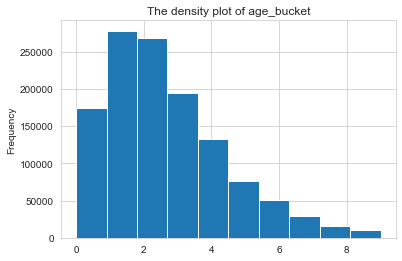

In [18]:
df['age_bucket'].plot(kind="hist", title="The density plot of age_bucket", bins=10)

#### generate lat long cluster

In [23]:
CENTROIDS = np.array([[36.68147669256268, -82.8910274009993],
                      [23.22243322909555, 78.23027450833709],
                      [50.04997682638993, 0.22379313938744885],
                      [37.9309447099281, -117.00741350764692],
                      [-32.795864819917725, 148.7159172660312],
                      [-18.570548393114084, -54.280255665692565],
                      [13.921140442819565, 116.38740315555172],
                      [29.78951080730802, 40.279515865947936]])

In [34]:
def classify(datapoint):
    """
    given a datapoint, compute the cluster closest to the
    datapoint. Return the cluster ID of that cluster.
    :param datapoint:
    :return: cluster ID
    """
    datapoints = np.tile(datapoint, (CENTROIDS.shape[0], 1))
    dists = np.sum((CENTROIDS - datapoints) ** 2, axis = 1)
    return np.argmin(dists)

In [36]:
df['lat_long_cluster'] = df[['user_location_latitude', 'user_location_longitude']].apply(lambda x: classify(x), axis = 1)

<AxesSubplot:title={'center':'The density plot of lat long cluster'}, ylabel='Frequency'>

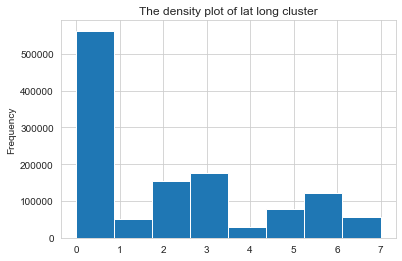

In [37]:
df['lat_long_cluster'].plot(kind="hist", title="The density plot of lat long cluster", bins=8)

In [40]:
df['country'].value_counts()

US                      664926
GB                       90175
BR                       50188
PH                       46693
CA                       45087
                         ...  
ST                           1
KENYA                        1
CK                           1
UNITED_ARAB_EMIRATES         1
GW                           1
Name: country, Length: 248, dtype: int64

#### Investigate model

In [141]:
df['model'].value_counts()

personalized    997940
cold_start      179939
fallback         51634
Name: model, dtype: int64

In [142]:
df['device'].value_counts()

android            768053
iphone             461458
tmg-live-search         2
Name: device, dtype: int64

#### outliers

In [41]:
df['view_duation'].describe(percentiles=np.linspace(0, 1, 21))

count    1.229513e+06
mean     2.662515e+00
std      1.460009e+02
min      0.000000e+00
0%       0.000000e+00
5%       0.000000e+00
10%      0.000000e+00
15%      0.000000e+00
20%      0.000000e+00
25%      0.000000e+00
30%      0.000000e+00
35%      0.000000e+00
40%      0.000000e+00
45%      0.000000e+00
50%      0.000000e+00
55%      0.000000e+00
60%      0.000000e+00
65%      0.000000e+00
70%      0.000000e+00
75%      0.000000e+00
80%      0.000000e+00
85%      0.000000e+00
90%      0.000000e+00
95%      0.000000e+00
100%     9.541900e+04
max      9.541900e+04
Name: view_duation, dtype: float64

In [43]:
df['view_duation'].quantile(.99)

8.0

In [45]:
df['bve_view_duration'].describe(percentiles=np.linspace(0, 1, 21))

count    1.229513e+06
mean     5.005500e+00
std      2.361749e+02
min      0.000000e+00
0%       0.000000e+00
5%       0.000000e+00
10%      0.000000e+00
15%      0.000000e+00
20%      0.000000e+00
25%      0.000000e+00
30%      0.000000e+00
35%      0.000000e+00
40%      0.000000e+00
45%      0.000000e+00
50%      0.000000e+00
55%      0.000000e+00
60%      0.000000e+00
65%      0.000000e+00
70%      0.000000e+00
75%      0.000000e+00
80%      0.000000e+00
85%      0.000000e+00
90%      0.000000e+00
95%      0.000000e+00
100%     9.541900e+04
max      9.541900e+04
Name: bve_view_duration, dtype: float64

In [47]:
df['bve_view_duration'].quantile(.99)

10.0

#### cutoff - quantile 0.99

In [49]:
cutoff = df['view_duation'].quantile(.99)

In [50]:
df['duration'] = df['view_duation'].apply(lambda x: cutoff if x > cutoff else x)

In [28]:
# broadcasters need more curate
# res = df.groupby(['broadcaster_id'])['viewer_id'].size().to_frame('size').reset_index()
# valid_broadcasters = set(res.loc[res['size'] > 1]['broadcaster_id'])
# df = df[df['broadcaster_id'].map(lambda x: x in valid_broadcasters)]

In [51]:
df_cp = df.copy()

In [52]:
df_cp.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1229513 entries, 98681243 to 95348623
Data columns (total 21 columns):
search_id                  1229513 non-null object
user_id                    1229513 non-null object
broadcast_id               1229513 non-null object
model                      1229513 non-null object
network                    1229513 non-null object
device                     1229513 non-null object
age                        1229513 non-null int64
gender                     1229480 non-null object
country                    1229487 non-null object
lang                       1229509 non-null object
user_locale                1229513 non-null object
user_location_latitude     1229513 non-null float64
user_location_longitude    1229513 non-null float64
offset                     1229513 non-null int64
views                      1229513 non-null int64
quality_view               1229513 non-null int64
view_duation               1229513 non-null int64
bve_view_durati

In [110]:
FEATURES = [
	'model',
	'device', 
	'network',
	'age_bucket',
	'gender',
	'lang',
	'country',
	'lat_long_cluster'
]

In [111]:
df_agg = (df_cp.groupby(FEATURES)
          .agg({'duration': np.mean, 'search_id': np.size})
          .reset_index()
         .rename(columns={'search_id': 'weight'}))

In [112]:
df_agg.describe(percentiles=np.linspace(0, 1, 11))

,age_bucket,lat_long_cluster,duration,weight
count,18881.000000,18881.000000,18881.000000,18881.000000
mean,3.006885,3.424819,0.089710,65.115725
std,2.430464,2.491676,0.497545,470.436803
min,0.000000,0.000000,0.000000,1.000000
0%,0.000000,0.000000,0.000000,1.000000
10%,0.000000,0.000000,0.000000,1.000000
20%,1.000000,1.000000,0.000000,1.000000
30%,1.000000,2.000000,0.000000,2.000000
40%,2.000000,2.000000,0.000000,3.000000
50%,3.000000,3.000000,0.000000,4.000000


In [113]:
df_agg['log_duration'] = df_agg['duration'].apply(lambda x: np.log(1+x))

In [114]:
df_agg.describe(percentiles=np.linspace(0, 1, 11))

,age_bucket,lat_long_cluster,duration,weight,log_duration
count,18881.000000,18881.000000,18881.000000,18881.000000,18881.000000
mean,3.006885,3.424819,0.089710,65.115725,0.053274
std,2.430464,2.491676,0.497545,470.436803,0.199358
min,0.000000,0.000000,0.000000,1.000000,0.000000
0%,0.000000,0.000000,0.000000,1.000000,0.000000
10%,0.000000,0.000000,0.000000,1.000000,0.000000
20%,1.000000,1.000000,0.000000,1.000000,0.000000
30%,1.000000,2.000000,0.000000,2.000000,0.000000
40%,2.000000,2.000000,0.000000,3.000000,0.000000
50%,3.000000,3.000000,0.000000,4.000000,0.000000


<AxesSubplot:ylabel='Frequency'>

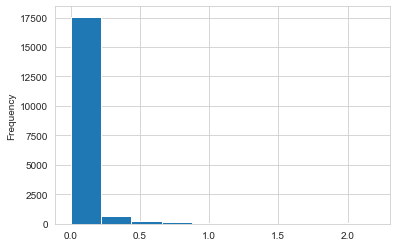

In [115]:
df_agg['log_duration'].plot(kind='hist', bins=10)

### Lightgbm Model

In [116]:
from typing import Dict, Iterable, Tuple
import lightgbm as lgb
import pandas as pd
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import train_test_split

In [117]:
def split(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """return distinct train and test sets"""
    return train_test_split(df, random_state=0, test_size=0.3)

In [118]:
def decompose(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series, pd.Series]:
    """break down data into features, labels and weights"""
    return df.drop(['y', 'w'], axis=1), df.y, df.w

In [119]:
def ungroup(X: pd.DataFrame, w: pd.DataFrame) -> pd.DataFrame:
    """expand all repeated columns"""
    return X.reindex(X.index.repeat(w))

In [120]:
def group(X: pd.DataFrame) -> pd.DataFrame:
    """append weight to pandas dataframe by groupby all columns"""
    return X.groupby(list(X.columns)).size().to_frame('w').reset_index()

In [121]:
def get_feature_mappings(X: pd.DataFrame) -> Dict[str, Dict[str, int]]:
    """map of value to pandas category"""
    return {
        f: {str(x): i
            for i, x in enumerate(X[f].cat.categories, start=1)}
        for f in X
    }

In [122]:
def etl(X: pd.DataFrame,
        y: pd.Series,
        w: pd.Series = None) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """transform the data"""
    X = X.assign(y=y)
    if w is not None:
        X_train, X_test = split(ungroup(X, w))
        return group(X_train), group(X_test)
    else:
        X['w'] = 1
        return split(X)

In [123]:
def predict(model: lgb.Booster,
            X: pd.DataFrame,
            regression: bool = False) -> pd.Series:
    """prediction wrapper"""
    return model.predict(X) if regression else model.predict_proba(X)[:, 1]

In [124]:
def evaluate(X: pd.DataFrame,
             y: pd.Series,
             w: pd.Series,
             y_pred: pd.Series,
             regression: bool = False) -> Dict[str, any]:
    """calculate evaluation metrics"""
    metrics = {'records': str(len(y)), 'weights': str(sum(w))}
    metrics['raw_accuracy'] = prediction_metrics(y, y_pred, weights=w)
    if not regression:
        metrics['log_loss'] = log_loss(y, y_pred, sample_weight=w)
        metrics['roc_auc_score'] = roc_auc_score(y, y_pred, sample_weight=w)
    return metrics

In [125]:
from sklearn import metrics
def prediction_metrics(var_y, var_y_pred, weights=None):
    if weights is None:
        weights = np.ones(len(var_y))
    avg = np.average(var_y, weights=weights)
    pred_avg = np.average(var_y_pred, weights=weights)
    bias2 = np.average(var_y - var_y_pred, weights=weights) ** 2
    var = np.average(var_y_pred ** 2, weights=weights) - np.average(var_y_pred, weights=weights) ** 2
    square_error = metrics.mean_squared_error(var_y, var_y_pred, weights)
    abs_err = metrics.mean_absolute_error(var_y, var_y_pred, weights)
    r2_score = metrics.r2_score(var_y, var_y_pred, weights)
    return dict(avg=avg, pred_avg=pred_avg, bias2=bias2, var=var, square_error=square_error, abs_err=abs_err, abs_err_ratio=abs_err / avg, r2_score=r2_score)

In [126]:
def build_model(
    X: pd.DataFrame,
    y: pd.Series,
    w: pd.Series = None,
    categories: Iterable[str] = [],
    unencoded_categories: Iterable[str] = [],
    params: Dict[str, any] = {},
    regression: bool = False
) -> Tuple[lgb.LGBMModel, Dict[str, any], pd.DataFrame, pd.DataFrame]:
    """take the sql data and output model and metadata"""
    X[unencoded_categories] = X[unencoded_categories].astype('category')
    metadata = {
        'model_type': 'lightgbm',
        'features': list(X),
        'category_features': categories,
        'mappings': get_feature_mappings(X[unencoded_categories]),
    }

    train_df, test_df = etl(X, y, w)
    X, y, w = decompose(train_df)
    
    model = (lgb.LGBMRegressor if regression else lgb.LGBMClassifier)(random_state=0, **params)
    model.fit(X, y, w, categorical_feature=categories)
    train_df['y_pred'] = predict(model, X, regression)
    
    metadata['train_accuracy'] = evaluate(X, y, w, train_df['y_pred'], regression)
    metadata['train_accuracy']['data_type'] = 'train'
    
    X, y, w = decompose(test_df)
    test_df['y_pred'] = predict(model, X, regression)
    metadata['test_accuracy'] = evaluate(X, y, w, test_df['y_pred'], regression)
    metadata['test_accuracy']['data_type'] = 'test'
    return model, metadata, train_df, test_df

In [127]:
pred_model, pred_metadata, train_df, test_df = build_model(
    X=df_agg[FEATURES],
    y=df_agg['log_duration'],
    w=df_agg['weight'],
    categories=FEATURES,
    unencoded_categories=FEATURES,
    params={'n_estimators': 300, 'num_leaves': 300, "learning_rate": 0.1, 'max_bin': 100},
    regression=True
)

/Users/lhuang/opt/miniconda3/envs/tensorflow2.5/lib/python3.7/site-packages/pandas/core/frame.py:3509: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[k1] = value[k2]
/Users/lhuang/opt/miniconda3/envs/tensorflow2.5/lib/python3.7/site-packages/lightgbm/basic.py:1551: UserWarning: Using categorical_feature in Dataset.
  warnings.warn('Using categorical_feature in Dataset.')
/Users/lhuang/opt/miniconda3/envs/tensorflow2.5/lib/python3.7/site-packages/sklearn/utils/validation.py:72: FutureWarning: Pass sample_weight=0        13
1        17
2         2
3        13
4         1
         ..
17120     1
17121     1
17122     2
17123    97
17124    28
Name: w, Length: 17125, dtype: int64 as keyword args. From version 1.0 (renaming of 0.25) passing these a

In [128]:
pred_metadata['train_accuracy']

{'records': '17125',
 'weights': '860615',
 'raw_accuracy': {'avg': 0.0993256384713266,
  'pred_avg': 0.09932566661406667,
  'bias2': 7.920138182136587e-16,
  'var': 0.004077820264205856,
  'square_error': 0.001712932848751667,
  'abs_err': 0.011561426784271368,
  'abs_err_ratio': 0.11639921939801001,
  'r2_score': 0.744977621890399},
 'data_type': 'train'}

In [129]:
pred_metadata['test_accuracy']

{'records': '13033',
 'weights': '368835',
 'raw_accuracy': {'avg': 0.09953016726633482,
  'pred_avg': 0.09937803069810504,
  'bias2': 2.3145535392732532e-08,
  'var': 0.004027423227175902,
  'square_error': 0.0019527854167327818,
  'abs_err': 0.011947382091769826,
  'abs_err_ratio': 0.12003779778446047,
  'r2_score': 0.7120669600058236},
 'data_type': 'test'}

In [130]:
train_df.head()

,model,device,network,age_bucket,gender,lang,country,lat_long_cluster,y,w,y_pred
0,cold_start,android,meetme,0,female,de,DE,2,0.0,13,0.001217
1,cold_start,android,meetme,0,female,en,AE,7,0.0,17,-0.002961
2,cold_start,android,meetme,0,female,en,AF,1,0.0,2,0.008595
3,cold_start,android,meetme,0,female,en,AU,4,0.0,13,0.015198
4,cold_start,android,meetme,0,female,en,AW,0,0.0,1,0.006202


In [131]:
train_df['y_pred_binned'] = pd.qcut(train_df['y_pred'], q=10)

In [132]:
train_df['y_pred_binned'].value_counts()

(0.184, 0.893]         1713
(0.085, 0.121]         1713
(0.023, 0.0394]        1713
(-0.00311, 0.00942]    1713
(-0.155, -0.0183]      1713
(0.121, 0.184]         1712
(0.059, 0.085]         1712
(0.0394, 0.059]        1712
(0.00942, 0.023]       1712
(-0.0183, -0.00311]    1712
Name: y_pred_binned, dtype: int64

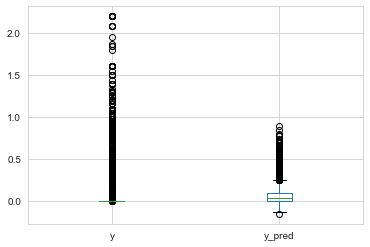

In [133]:
plt.figure()
boxplot = train_df.boxplot(column=['y', 'y_pred'])

In [134]:
def cnt_distinct(x):
    return len(set(x))

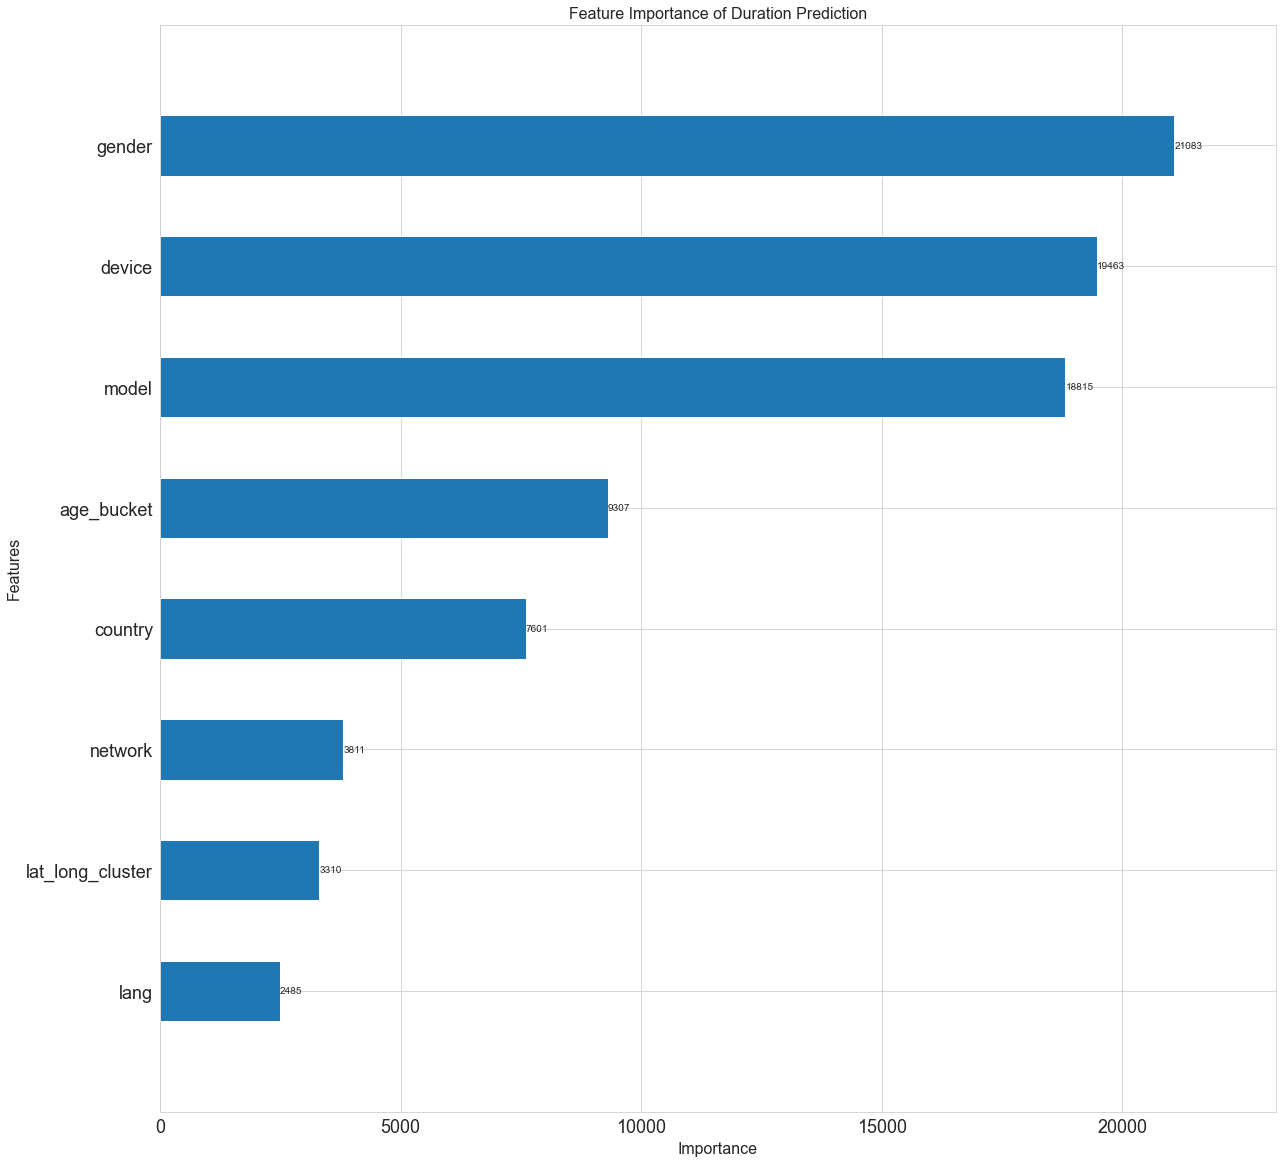

In [135]:
lgb.plot_importance(pred_model, figsize=(20,20), height=0.5)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title("Feature Importance of Duration Prediction", fontsize=16)
plt.xlabel("Importance", fontsize=16)
plt.ylabel("Features", fontsize=16)
plt.show()